# Predicting stellar spectra and SED with `FASTAR`
The core of `FASTAR` is its PCA-based, neural network stellar regressor. It is used in the synthesis of evolutionary models but can also be used to predict stellar spectra given a set of atmospheric parameters

In [1]:
import numpy as np

from matplotlib import pyplot as plt
from fastar.core.stellar_predictions import StellarSynthesizer

/home/imartin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Basic functionalities
### 1. Spectroscopic predictions

In [ ]:
# First, load the stellar synthesizer.
stellar_spec = StellarSynthesizer()

# Get the wavelength
wave_spec = stellar_spec.wave

# Then specify the desired atmospheric parameters
teff = np.log10(5000)
logg = 0.7
fmet = 0.3

# Get the spectrum
spec = stellar_spec.predict_spectrum(logg,teff,fmet)

# Normalize it over a wavelength range
b1 = 6000
b2 = 6100
sgood = (wave_spec > b1) & (wave_spec < b2)
spec  = spec / np.median(spec[sgood])

### 2. Photometric predictions

In [5]:
# Similarly, an SED model for photometric predictions 
# can also be generated.
#
# The only difference is that the stellar synthesizer 
# has to be loaded using the photometric model
stellar_phot = StellarSynthesizer(model_label='phot')

# We repeat the process by getting the wavelengths,
# which cover a wider range in this case
wave_phot = stellar_phot.wave

# In this case, we use the same parameters
teff = np.log10(5000)
logg = 0.7
fmet = 0.3

# Get the spectrum
phot = stellar_phot.predict_spectrum(logg,teff,fmet)

# Normalize it over the same wavelength range
b1 = 6000
b2 = 6100
pgood = (wave_phot > b1) & (wave_phot < b2)
phot  = phot / np.median(phot[pgood])

### 3. Combine spectrum and SED

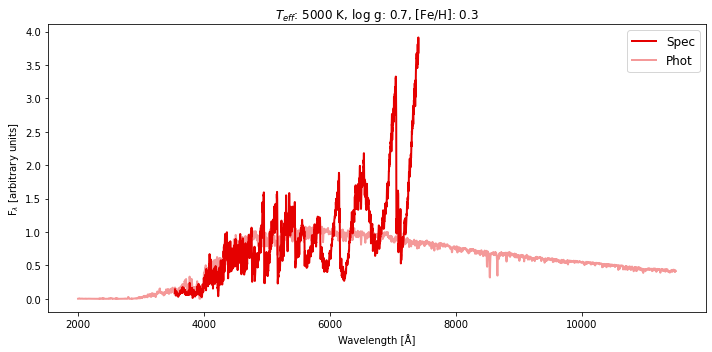

In [6]:

# Let's see how it looks
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave_spec, spec, color='xkcd:red', linewidth=2, label='Spec')
ax.plot(wave_phot, phot, color='xkcd:red', linewidth=2, alpha=0.4,  label='Phot')
ax.legend(fontsize=12)
ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('F$_\lambda$ [arbitrary units]')
ax.set_title(rf"$T_{{eff}}$: {int(np.round(10**teff, 0))} K, log g: {0.7}, [Fe/H]: {fmet}")
fig.tight_layout()
plt.show()